<a href="https://colab.research.google.com/github/gbebyn/HelloAgents/blob/main/RL_Assignment_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Robot Learning

## Assignment 7

Solutions are due on 16.06.2026 before the lecture.

### Introduction

On this assignment sheet, we will use an environment from [OpenAi Gym](https://github.com/openai/gym). The setup requires some further packages. Since this installation is not trivial, and we could only test it in our setup, we strongly recommend that you execute the cells in this notebook in [Google Colab](https://research.google.com/colaboratory/). You should find a button which opens this file directly in Colab at the top of this notebook. If not, you can simply import the .ipynb manually.

If you have started your Colab session and are ready to proceed, uncomment the lines in the code cell below. They will install everything required to simulate the Gym environment. If prompted to restart your runtime, do so, but you don't have to repeat the installation unless you delete your runtime.

**Warning: This is unlikely to work on your own computer, and might even mess up your system! Please only use the following lines in Colab. If you insist on using your own machine, please refer to installation instructions for Gym, torch and the box2d environments for your system.**

In [4]:
!apt-get -qq install xvfb x11-utils &> /dev/null
!pip install ufal.pybox2d --quiet &> /dev/null
!pip install pyvirtualdisplay moviepy pyglet PyOpenGL-accelerate --quiet &> /dev/null
!pip install numpy==1.26.2 matplotlib==3.7.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 21.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached numpy-1.26.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.9 MB)
  Created wheel for matplotlib: filename=matplotlib-3.7.0-cp312-cp312-linux_x86_64.whl size=11117019 sha256=489619cf8439d430ecd2f29b325d616b8c265551e7d038577928e55c8b38f79a
  Stored in directory: /root/.cache/pip/wheels/b8/6d/92/e1f524b34cb5f0fda14c19ad64ac2a73095c763004432e45a1
Successfully built matplotlib
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalle

The following cell imports packages required for the task.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import gym
import matplotlib.pyplot as plt
from pyvirtualdisplay import Display
from moviepy.editor import VideoClip
from moviepy.video.io.bindings import mplfig_to_npimage
import torch
import torch.nn as nn
from tqdm import tqdm
import random


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294

## Task 7.1)

Your agent is in state $s_t$ and has the $Q$-values $Q(s_t,a) = [Q(s_t,a_0), Q(s_t,a_1), Q(s_t,a_2), Q(s_t,a_3)] = [7, 6, 2, 12]$. If the agent samples its action according to a probabilistic policy $\pi(s_t,a)$ which is created by softmax action selection from $Q(s_t,a)$, then what is the probability $Pr(a_2 | s_t)$ of taking action $a_2$ in state $s_t$?

<div style="text-align: right; font-weight:bold"> 3 Points </div>

Please answer in this text cell.

$$
Pr(a_2|s_t)=\frac{e^{Q(s_t,a_2)}}{\sum_i e^{Q(s_t,a_i)}}
=\frac{e^2}{e^7+e^6+e^2+e^{12}}
\approx 0.000045
$$

## Task 7.2)

In this task, we will combine an actor-critic method like on the previous sheet with a policy gradient algorithm to control an agent in a challenging environment: the Lunar Lander.

In [2]:
# set up showing animations from the environment in Colab.
Display(visible=False).start()

  return datetime.utcnow().replace(tzinfo=utc)



Examine the code cell below. It has two distinct purposes:

* Showcase the agent-environment interaction for LunarLander-v2

* Show how you can capture frames from this environment to animate an episode afterwards.

Note that for training an agent in this environment, it is advisable to omit all code corresponding to the rendering. You can seperately render an episode of your agent's play afterwards.


In [3]:
# Name of the environment, if you are having problems you can switch to 'CartPole-v1', which is easier to solve.
ENV_NAME = 'LunarLander-v2' #'CartPole-v1'
# Dimension of the LunarLander state space. For 'CartPole-v1', use 4 instead
ENV_STATE_DIM =  8 # 4
# Lunar Lander has 4 discrete actions: [Do Nothing, Fire Left Booster, Fire Main Engine, Fire Right Booster], 'CartPole-v1' has 2
ENV_ACTION_DIM = 4 # 2
# If the agent reaches this score the task is seen as solved
SCORE_TO_SOLVE = 200 # 195
MAX_STEPS = None # 500
# Create the environment
env = gym.make(ENV_NAME)
# Reset the environment
state = env.reset() # state = [x, y, dx, dy, theta, dtheta, leg1_contact, leg2_contact]
# Track whether the episode is over
done = False
# List to append the frames produced by the environment renderer
frames = []
while not done:
  # Render current situation and append to frames
  frames.append(env.render('rgb_array'))
  # Select a random action
  action = env.action_space.sample()
  # Execute this action
  state, reward, done, info = env.step(action)
# Print the number of frames
print('Number of frames:', len(frames))
# Prevent the renderer from showing artifacts
plt.close()

  deprecation(

  deprecation(

See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(

  if not isinstance(terminated, (bool, np.bool8)):



Number of frames: 78


In [4]:
# Helper function to animate a list of frames as produced above
def visualize_trajectory(frames, fps=50):
  duration = int(len(frames) // fps + 1)
  fig, ax = plt.subplots()
  def make_frame(t, ind_max=len(frames)):
      ax.clear()
      ax.imshow(frames[min((int(fps*t),ind_max-1))])
      return mplfig_to_npimage(fig)
  plt.close()
  return VideoClip(make_frame, duration=duration)

In [5]:
# Get the animation from the frames of the played episode
animation = visualize_trajectory(frames)
# Show the animation
animation.ipython_display(fps=50, loop=True, autoplay=True)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


Probably, the random agent will destroy itself instead of landing between the two flags. We would like you to improve upon this. Below, you are given a neural net with learnable weights $\theta$ which takes an environment state $s_t$ as input and can output either a state value $V_{\theta}(s_t)$ or a probability distribution over the actions $\pi_{\theta}(s_t,a)$.

In [6]:
# If you feel like it, you can, but you do not need to adapt this
class DualNet(nn.Module):
    def __init__(self, state_dim=ENV_STATE_DIM, action_dim=ENV_ACTION_DIM, hidden_layer_dim=42):
        super(DualNet, self).__init__()
        # Create some layers to encode the input state
        self.layers = [nn.Linear(state_dim, hidden_layer_dim),
                       nn.LeakyReLU()]
        # Combine these layers into a net
        self.net = nn.Sequential(*self.layers)
        # Critic output layers to estimate V from the state encoding
        self.critic = nn.Sequential(*[nn.Linear(hidden_layer_dim,1)])
        # Actor output layers to estimate pi from the state encoding
        self.actor = nn.Sequential(*[nn.Linear(hidden_layer_dim,action_dim),
                                        nn.Softmax(dim=-1)])
    def forward(self, s, mode):
        # Convert input state to tensor
        device = next(self.net.parameters()).device
        x = torch.tensor(s).float().view(1,-1).to(device)
        # Encode state
        x = self.net(x)
        if mode == 'actor':
          # Return probability distribution over actions
          x = self.actor(x)
        else:
          # Return estimate of state value
          x = self.critic(x)
        return x.squeeze()

# Example usage:
# Create instance of the DualNet class
test_net = DualNet()
# Create a dummy state, round just for pretty printing
test_input = np.around(np.random.rand(ENV_STATE_DIM),2)
# Get the actor output
actor_out = test_net(test_input, mode='actor')
# Get the critic output
critic_out = test_net(test_input, mode='critic')
print('Dummy Input:', test_input)
print('Actor output:', actor_out)
print('Critic output:', critic_out)

Dummy Input: [0.76 0.72 0.95 0.67 0.46 0.05 0.75 0.75]
Actor output: tensor([0.2426, 0.2738, 0.2156, 0.2680], grad_fn=<SqueezeBackward0>)
Critic output: tensor(0.2686, grad_fn=<SqueezeBackward0>)


Now to the task: Play episodes according to the following scheme:

* For each visited state $s_t$, store the output of the critic $V_\theta(s_t)$ in a list.

* Select an action $a_t$ by sampling from the distribution $\pi_{\theta}(s_t,a)$ output by the actor. In a list, store the log prob of the action: $l_t = log(\pi_{\theta}[s_t,a_t])$.

* Execute the action and observe the reward $r_{t+1}$ provided by the environment.

After each episode, use the stored rewards to calculate the Returns $R_t$ following each state $s_t$ using the discount factor $\gamma$. Next, calculate for each $t$

$$\delta_t = R_t - V_{\theta}(s_t)$$

Then, calculate the loss of the critic as

$$L_{critic} = 0.5 \sum_t \delta_t^2$$

and the loss of the actor using the log probs as

$$L_{actor} = \sum_t - l_t  \delta_t$$

and finally the total loss

$$L = L_{critic} + L_{actor}$$

Now, update the parameters $\theta$ using

$$\theta \leftarrow \theta + \alpha \nabla_{\theta}L$$

The Lunar Lander problem is considered solved when the agent achieves an average return of 200 over 100 episodes. Solve the problem, or play around 3000 episodes as described above and then report the average return of the final 100 episodes played. This means that you are welcome to preemptively stop training if the average return is sufficient. Then, play one more episode and animate it like in the example above. Use $\gamma = 0.99$ in your experiments. Save your final animation and place it into your sciebo folder along with this notebook. We recommend starting with a learning rate of $\alpha = 0.02$, but please note that this parameter might be sensitive to the specifics of your implementation. Solving the environment should not take longer than an hour, but we have seen implementations that completed the task in as little as 10 minutes.

### Hints:

Following tips might help you complete this task:

* You might need to convert your return $R_t$ to the correct datatype:

$$\delta_t = torch.tensor(R_t) - V_{\theta}(s_t)$$

* If you want to use numpy to sample from $\pi_{\theta}(s_t,a)$, you can get a numpy array by calling

$$\pi_{\theta}(s_t,a).detach().numpy()$$

* When you calculate the log probs $l_t$, preserve the torch gradient graph by using the torch function

$$l_t = torch.log(\pi_{\theta}[s_t,a_t])$$

* When you calculate $L_{actor}$, use $\delta_t.item()$ to ensure that the actor's loss does not directly influence the critic's gradients.

* It might be easier to solve the task for the Cart-Pole environment first, just change ENV_NAME, ENV_STATE_DIM and ENV_ACTION_DIM in one of the previous code blocks.

* Standardizing the Returns (zero mean and std 1) before calculating $\delta_t$ can boost performance.

* Below you are already given a rough structure for the algorithm. If you stick to it, torch will compute and apply $\nabla_{\theta}L$ for you!

<div style="text-align: right; font-weight:bold"> 10 +  3 (animation) Points </div>

In [7]:
# Complete this code or write your own!
# Create the environment
env = gym.make(ENV_NAME)
# Get the combined actor and critic model
net = DualNet()
# if using a gpu runtime DualNet().cuda() moves the policy to GPU
# in this case, use .cpu() on a tensor before converting to numpy
# Number of episodes to play, maybe use fewer at first
num_iter = 3000
# Learning rate for the parameter updates
alpha = 2e-2
# Discount factor
gamma = 0.99
# The optimizer will do the gradient updates for you
# It needs the trainable parameters and a learning rate
optimizer = torch.optim.RMSprop(net.parameters(), lr=alpha)
# feel free to experiment with other torch optimizers
episode_returns = []

# This progress_bar is useful to know how far along the training is
progress_bar = tqdm(range(num_iter), total=num_iter, position=0, leave=True)
# For each episode (episode can be used like an int)
for episode in progress_bar:
    # Reset the accumulated gradients of the model parameters
    optimizer.zero_grad()
    # Reset the environment and observe the starting state
    s = env.reset()
    done = 0
    # Collect the following terms during the episode
    rewards = []
    state_vals = []
    log_probs = []
    while not done:
        # During each Episode:
        # Evaluate the critic for s, store it
        state_val = net(s, mode='critic')
        state_vals.append(state_val)

        # Evaluate the actor for s, and calculate the probability of each action
        action_probs = net(s, mode='actor')

        # Sample a from the distribution given by the actor
        dist = torch.distributions.Categorical(action_probs)
        a = dist.sample()

        # Store log_prob of a
        log_prob = dist.log_prob(a)
        log_probs.append(log_prob)

        # Execute action
        step_out = env.step(a.item())

        # Compatible with gymnasium and old gym
        if len(step_out) == 5:
            next_s, r, terminated, truncated, info = step_out
            done = terminated or truncated
        else:
            next_s, r, done, info = step_out

        rewards.append(r)
        s = next_s


    # After each episode is done
    # Calculate the Returns from the episode. Use rewards and gamma
    returns = []
    R = 0

    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    returns = torch.tensor(returns).float()

    # You might want to standardize the Returns
    # Optional standardization, often helps training stability
    if len(returns) > 1:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # Calculate delta_t, L_actor, L_critic
    state_vals = torch.stack(state_vals)
    log_probs = torch.stack(log_probs)

    # delta_t = R_t - V(s_t)
    deltas = returns - state_vals

    # Critic loss: make V(s_t) closer to R_t
    L_critic = 0.5 * torch.sum(deltas ** 2)

    # Actor loss: increase probability of good actions, decrease probability of bad actions
    L_actor = torch.sum(-log_probs * deltas.detach())

    # Calculate the loss L
    L = L_critic + L_actor
    L.backward()
    optimizer.step()

    episode_return = sum(rewards)
    episode_returns.append(episode_return)

    if episode % 10 == 0 and episode > 99:
        avg_return = np.mean(episode_returns[-100:])
        episode_summary = [
            f"Episode {episode+1} | ",
            f"Return: {episode_return:.1f} | ",
            f"Avg100: {avg_return:.1f}"
        ]
        progress_bar.set_description("".join(episode_summary))

    if len(episode_returns) >= 100 and np.mean(episode_returns[-100:]) >= SCORE_TO_SOLVE:
        print(f"Solved after {episode+1} episodes!")
        break

  return datetime.utcnow().replace(tzinfo=utc)

  0%|          | 0/3000 [00:00<?, ?it/s]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):

Episode 2991 | Return: 234.0 | Avg100: 136.1: 100%|██████████| 3000/3000 [1:23:28<00:00,  1.67s/it]


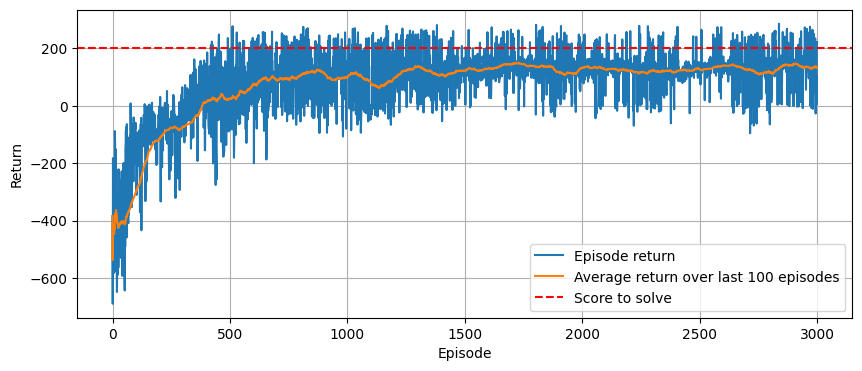

  deprecation(

  deprecation(

  if not isinstance(terminated, (bool, np.bool8)):



Final 100 episode average: 135.16988768795383
Evaluation episode return: 161.64477481535454
Number of frames: 1000
Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


In [11]:
# Your code for showing the results can go here

# Your code for showing the results can go here

# Plot episode returns
plt.figure(figsize=(10, 4))
plt.plot(episode_returns, label="Episode return")

if len(episode_returns) >= 100:
    moving_avg = [
        np.mean(episode_returns[max(0, i - 99):i + 1])
        for i in range(len(episode_returns))
    ]
    plt.plot(moving_avg, label="Average return over last 100 episodes")

plt.axhline(SCORE_TO_SOLVE, color="red", linestyle="--", label="Score to solve")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.grid()
plt.show()

print("Final 100 episode average:", np.mean(episode_returns[-100:]))


# Play one episode with the trained agent and collect frames
try:
    eval_env = gym.make(ENV_NAME, render_mode="rgb_array")
except TypeError:
    eval_env = gym.make(ENV_NAME)

reset_out = eval_env.reset()
s = reset_out[0] if isinstance(reset_out, tuple) else reset_out

done = False
frames = []
total_reward = 0

while not done:
    # Render frame
    try:
        frame = eval_env.render()
    except TypeError:
        frame = eval_env.render("rgb_array")

    # Fix possible frame shapes
    frame = np.asarray(frame)

    # Some gym versions return shape (1, H, W, 3), but imshow needs (H, W, 3)
    if frame.ndim == 4 and frame.shape[0] == 1:
        frame = frame[0]

    frames.append(frame)

    # Use the trained actor to choose action
    with torch.no_grad():
        action_probs = net(s, mode="actor")
        a = torch.argmax(action_probs).item()

        # If you want stochastic action instead, use:
        # dist = torch.distributions.Categorical(action_probs)
        # a = dist.sample().item()

    step_out = eval_env.step(a)

    if len(step_out) == 5:
        next_s, r, terminated, truncated, info = step_out
        done = terminated or truncated
    else:
        next_s, r, done, info = step_out

    total_reward += r
    s = next_s

eval_env.close()

print("Evaluation episode return:", total_reward)
print("Number of frames:", len(frames))


# Create and show animation
# Fix frame shapes first
fixed_frames = []

for frame in frames:
    frame = np.asarray(frame)

    # If frame is (1, H, W, 3), convert to (H, W, 3)
    if frame.ndim == 4 and frame.shape[0] == 1:
        frame = frame[0]

    fixed_frames.append(frame)

frames = fixed_frames

# Show the animation using the helper function from the notebook
animation = visualize_trajectory(frames)

animation.ipython_display(
    fps=50,
    loop=True,
    autoplay=True
)

## Task 7.3)

In the previous task, you calculate the loss of the policy network as

$$L_{actor} = \sum_t - log(\pi_{\theta}[s_t,a_t])  \delta_t$$

with

$$\delta_t = R_t - V_{\theta}(s_t).$$

Give an intuitive explanation why minimizing this term leads to actions with a good outcome being more likely and actions with a bad outcome becoming less likely.

<div style="text-align: right; font-weight:bold"> 4 Points </div>

Please answer in this text cell.